In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
import copy
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
np.random.seed(0)

In [4]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')
root_folder = '/content/drive/MyDrive/OIST-mini-course'
!ls $root_folder

Mounted at /content/drive
cls_train.pkl
cls_val.pkl
code001_part-A_setup.ipynb
code001_part-B_setup.ipynb
code001_setup_readme.docx
code001_setup_readme.pdf
code002_data_prep_NN.ipynb
code003_LogReg.ipynb
code004_DNN_scratch.ipynb
code005_part-A_detection_dataPrep.ipynb
code005_part-B_pollen_detection_model_design.ipynb
code005_part-C_pollen_detection_training.ipynb
code006_part-A_DNN_finetune.ipynb
code006_part-B_pollen_detection_finetune.ipynb
dataset_for_classification
dataset_for_classification.zip
dataset_for_detection
dataset_for_detection.zip
det_trainval_splits.pkl
meta_detection.pkl
slides
test-image.jpg
test-image-sharpened.jpg


# load the train&val sets

In [5]:
filename_train = os.path.join(root_folder, 'cls_train.pkl')
filename_val = os.path.join(root_folder, 'cls_val.pkl')

In [6]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [7]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [8]:
len(trainset_info['train_imgpathlist']), len(valset_info['val_imgpathlist'])


(480, 120)

In [9]:
val_imgs = []
i = 0
for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    im = im[:,:,0]
    val_imgs += [im.astype(np.float32)]
    i+=1
    if i%100==0:
        print(i, len(valset_info['val_imgpathlist']))

100 120


In [10]:
train_imgs = []

i = 0
for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    im = im[:,:,0]
    train_imgs += [im.astype(np.float32)]
    i+=1
    if i%100==0:
        print(i, len(trainset_info['train_imgpathlist']))




100 480
200 480
300 480
400 480


(391, 391)


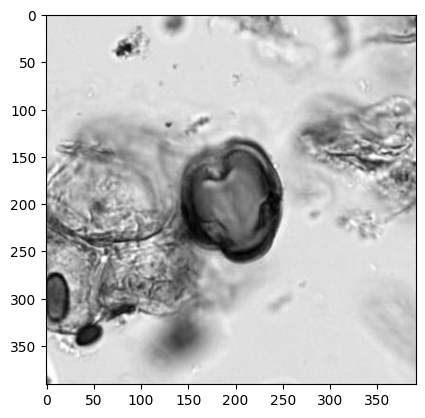

In [11]:
# visualize a random image
idx = 10
img = val_imgs[idx]
print(img.shape)
plt.imshow(img.astype(np.uint8), 'gray')

(391, 391)


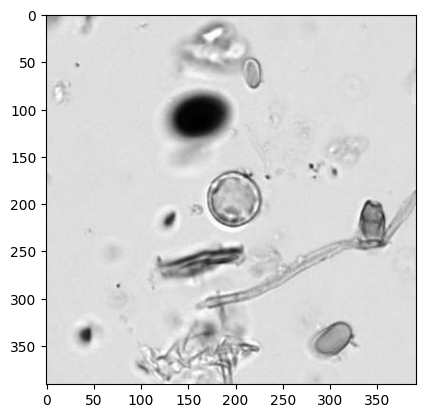

In [12]:
# visualize a random image
idx = 10
img = train_imgs[idx]
print(img.shape)
plt.imshow(img.astype(np.uint8), 'gray')

# Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

train_imgs_original = copy.deepcopy(train_imgs)
val_imgs_original = copy.deepcopy(val_imgs)

In [14]:
for i in range(len(train_imgs)):
    im = train_imgs[i] # as it is gray scale, let's simply use the first channel
    im = np.reshape(im,(1,-1))
    train_imgs[i] = im

for i in range(len(val_imgs)):
    im = val_imgs[i] # as it is gray scale, let's simply use the first channel
    im = np.reshape(im,(1,-1))
    val_imgs[i] = im

In [15]:
train_imgs = np.asarray(train_imgs).squeeze()
val_imgs = np.asarray(val_imgs).squeeze()

train_imgs = train_imgs.reshape(train_imgs.shape[0],-1)
val_imgs = val_imgs.reshape(val_imgs.shape[0],-1)

train_labellist = np.asarray(train_labellist)
val_labellist = np.asarray(val_labellist)

print(train_imgs.shape)
print(train_labellist.shape)

print(val_imgs.shape)
print(val_labellist.shape)

(480, 152881)
(480,)
(120, 152881)
(120,)


In [16]:
clf = LogisticRegression(verbose=1, max_iter=1000).fit(train_imgs, train_labellist)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.2min finished


In [17]:
predList = clf.predict(val_imgs)

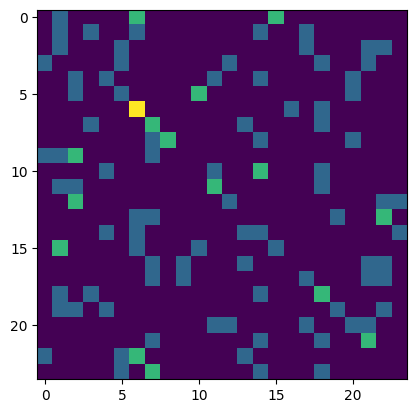

In [18]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [19]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.183


# crop the center region (200x200-pixel resolution) towards "better features"

In [20]:
X_train = np.asarray(train_imgs_original)
X_val = np.asarray(val_imgs_original)

In [21]:
X_val.shape

(120, 391, 391)

In [22]:
X_train = np.asarray(train_imgs_original)
X_train = X_train[:,
                  X_train.shape[1]//2-50:X_train.shape[1]//2+50,
                  X_train.shape[2]//2-50:X_train.shape[2]//2+50
                  ] # suppose the new feature is a 100x100 square region in image center



# do the same feature extraction for validation images
X_val = np.asarray(val_imgs_original)
X_val = X_val[:,
              X_val.shape[1]//2-50:X_val.shape[1]//2+50,
              X_val.shape[2]//2-50:X_val.shape[2]//2+50
              ]


(100, 100)


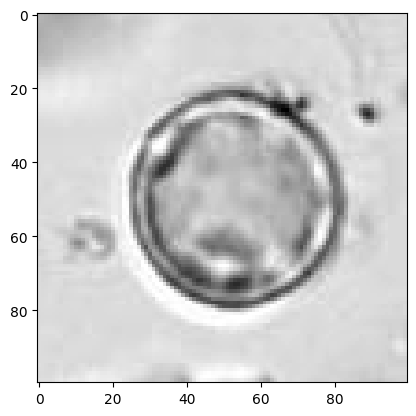

In [23]:
# visualize a random image
idx = 10
img = X_train[idx]
print(img.shape)
plt.imshow(img.astype(np.uint8), 'gray')

In [24]:
X_train = X_train.reshape(X_train.shape[0], -1) /255
X_val = X_val.reshape(X_val.shape[0], -1) /255

print(X_train.shape, X_val.shape)

(480, 10000) (120, 10000)


In [25]:
clf = LogisticRegression(verbose=1, max_iter=2000, C=1.0, solver='lbfgs', penalty='l2').fit(X_train, train_labellist)
predList = clf.predict(X_val)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  4.8min finished


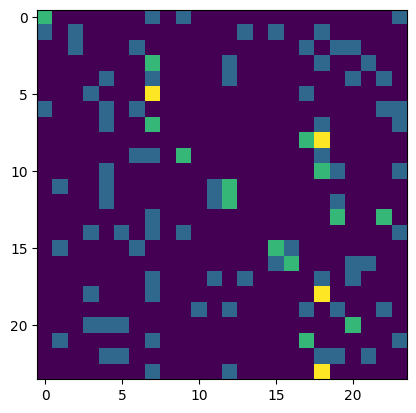

In [26]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [27]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.183


# sharpened images as new features

In [54]:
X_train = np.asarray(train_imgs_original)
X_train = X_train[:,
                  X_train.shape[1]//2-50:X_train.shape[1]//2+50,
                  X_train.shape[2]//2-50:X_train.shape[2]//2+50
                  ] # suppose the new feature is a 100x100 square region in image center



# do the same feature extraction for validation images
X_val = np.asarray(val_imgs_original)
X_val = X_val[:,
              X_val.shape[1]//2-50:X_val.shape[1]//2+50,
              X_val.shape[2]//2-50:X_val.shape[2]//2+50
              ]


(100, 100)


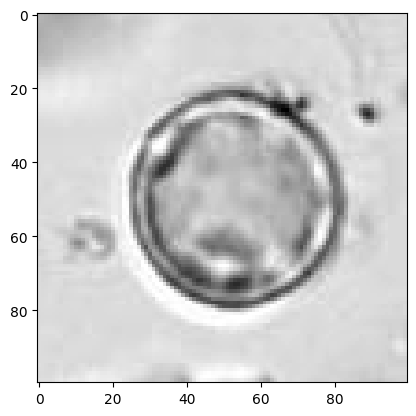

In [55]:
 # visualize a random image
idx = 10
img = X_train[idx]
print(img.shape)
plt.imshow(img.astype(np.uint8), 'gray')

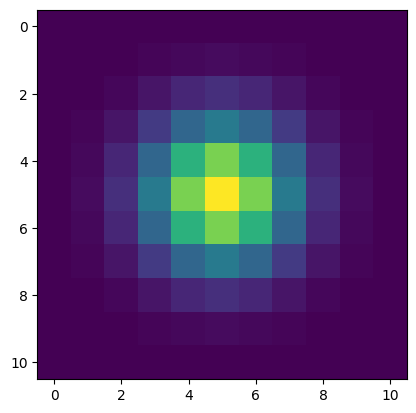

In [56]:
# define a function to create Gaussian filter
def create_gaussian_kernel(filter_size, sigma):
    """Creates a 2D Gaussian kernel."""
    kernel = np.zeros((filter_size, filter_size), dtype=np.float32)
    center = filter_size // 2
    x, y = np.meshgrid(np.arange(-center, center + 1), np.arange(-center, center + 1))
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * filter_sigma**2))
    return kernel / np.sum(kernel) # Normalize the kernel


filter_size = 11
filter_sigma = 1.5
gaussian_filter = create_gaussian_kernel(filter_size, filter_sigma)

plt.imshow(gaussian_filter)

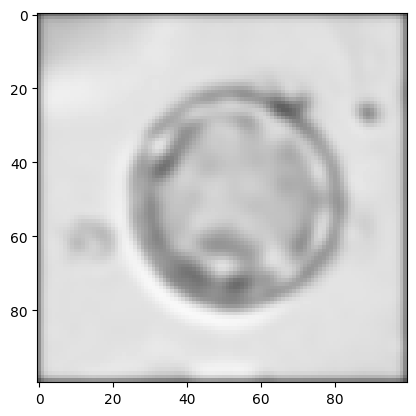

In [58]:
from scipy import signal # let's use a third-part toolbox called scipy to convolve an image with a defined filter


filter_size = 11
filter_sigma = 1.5
gaussian_filter = create_gaussian_kernel(filter_size, filter_sigma)
img_gauss_blurred = signal.convolve2d(img, gaussian_filter, 'same')
plt.imshow(img_gauss_blurred, cmap='gray', vmin=0, vmax=255)

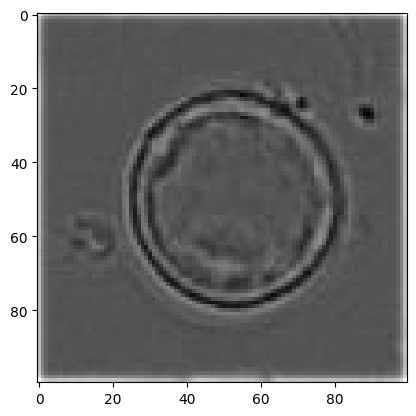

In [59]:
unsharp_mask = img - img_gauss_blurred
plt.imshow(unsharp_mask, 'gray')

Text(0.5, 1.0, 'magnifier=2.0')

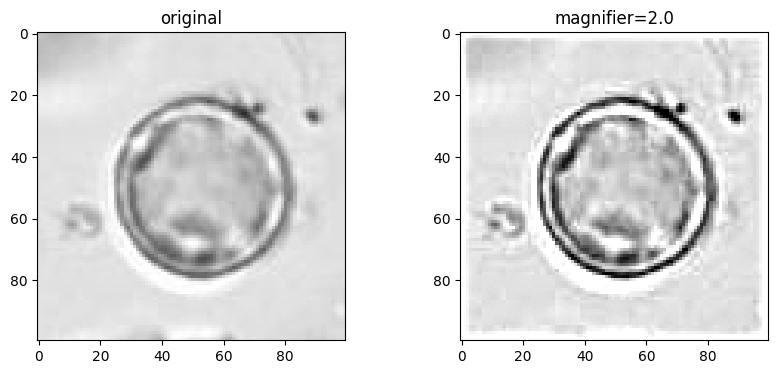

In [60]:
magnifier = 2.0
img_new = img + magnifier*unsharp_mask

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('original')

plt.subplot(1, 2, 2)
plt.imshow(img_new, cmap='gray', vmin=0, vmax=255)
plt.title('magnifier=%.1f' % magnifier)

In [61]:
for i in range(X_train.shape[0]):
  if i%100==0:
    print(i, X_train.shape[0])
  img = X_train[i]
  img_gauss_blurred = signal.convolve2d(img, gaussian_filter, 'same')
  unsharp_mask = img - img_gauss_blurred
  img_new = img + magnifier*unsharp_mask
  X_train[i] = img_new


for i in range(X_val.shape[0]):
  if i%100==0:
    print(i, X_val.shape[0])
  img = X_val[i]
  img_gauss_blurred = signal.convolve2d(img, gaussian_filter, 'same')
  unsharp_mask = img - img_gauss_blurred
  img_new = img + magnifier*unsharp_mask
  X_val[i] = img_new


0 480
100 480
200 480
300 480
400 480
0 120
100 120


In [62]:
X_train = X_train.reshape(X_train.shape[0], -1) /255
X_val = X_val.reshape(X_val.shape[0], -1) /255

print(X_train.shape, X_val.shape, X_train.max(), X_train.min(), X_val.max(), X_val.min())

(480, 10000) (120, 10000) 2.3407657 -0.5382518 2.3775983 -0.4587327


In [63]:
clf = LogisticRegression(verbose=1, max_iter=1000, C=1.0, solver='lbfgs', penalty='l2').fit(X_train, train_labellist)
predList = clf.predict(X_val)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.5min finished


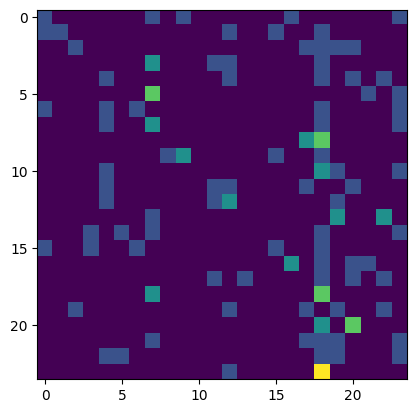

In [64]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [65]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.183


# SVM, another linear classifier

In [77]:
from sklearn import svm

In [78]:
X_train = np.asarray(train_imgs_original)
X_train = X_train[:,
                  X_train.shape[1]//2-50:X_train.shape[1]//2+50,
                  X_train.shape[2]//2-50:X_train.shape[2]//2+50
                  ] # suppose the new feature is a 100x100 square region in image center



# do the same feature extraction for validation images
X_val = np.asarray(val_imgs_original)
X_val = X_val[:,
              X_val.shape[1]//2-50:X_val.shape[1]//2+50,
              X_val.shape[2]//2-50:X_val.shape[2]//2+50
              ]

In [79]:
X_train = X_train.reshape(X_train.shape[0], -1) /255
X_val = X_val.reshape(X_val.shape[0], -1) /255

print(X_train.shape, X_val.shape)

(480, 10000) (120, 10000)


In [80]:
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X_train, train_labellist)

# Predict a new data point
prediction = clf.predict(X_val)


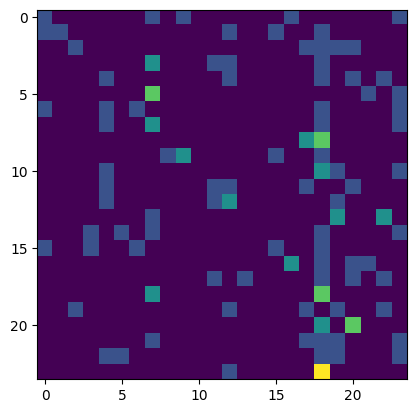

In [81]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [82]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.183
